# Measuring AI-Generated Content in Irish News — Presentation EDA


## Setup

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [26]:
ROOT = Path.cwd().parent
DATA = ROOT / 'data'
DET_DIR = DATA / 'detection'
DETECTORS = ['perplexity', 'radar', 'binoculars', 'fastdetectgpt']

CATEGORY_ORDER = ['Legacy', 'Counter-consensus']
OUTLET_ORDER = ['rte', 'irish_examiner', 'the_liberal', 'gript']
PERIOD_ORDER = ['pre', 'post']
CATEGORY = {
    'rte': 'Legacy',
    'irish_examiner': 'Legacy',
    'the_liberal': 'Counter-consensus',
    'gript': 'Counter-consensus',
}

META_COLS = [
    'article_id',
    'outlet',
    'published_date',
    'year',
    'month',
    'period',
    'section',
    'author',
    'is_wire',
    'word_count',
]

SCORE_COLS = [f'{detector}_score' for detector in DETECTORS]


In [27]:
def load_scores(detector: str) -> pd.Series:
    """Load one detector's corpus scores keyed by article_id.

    Args:
        detector (str): Detector name.

    Returns:
        pd.Series: Float scores indexed by article_id, named <detector>_score.

    """
    frame = pd.read_csv(DET_DIR / f'{detector}.csv')
    frame.columns = ['id', 'score']
    corpus = frame[frame['id'].str.startswith('corpus:')].copy()
    corpus['article_id'] = corpus['id'].str.removeprefix('corpus:')
    return (
        corpus.set_index('article_id')['score'].astype(float).rename(f'{detector}_score')
    )

In [28]:
df = pd.read_csv(DATA / 'corpus.csv', usecols=META_COLS)
df['category'] = df['outlet'].map(CATEGORY)
df['article_id'] = df['article_id'].astype(str)
for detector in DETECTORS:
    df = df.join(load_scores(detector), on='article_id')

df[['outlet', 'period', 'category', 'word_count', 'article_id', *SCORE_COLS]].head()

,outlet,period,category,word_count,article_id,perplexity_score,radar_score,binoculars_score,fastdetectgpt_score
0,gript,post,Counter-consensus,597,24151,-2.684621,0.010507,-0.988321,0.099189
1,gript,post,Counter-consensus,1082,24152,-2.503251,0.011878,-1.002437,-1.641121
2,gript,post,Counter-consensus,844,24153,-3.096333,0.011502,-1.018009,-1.473422
3,gript,post,Counter-consensus,1010,24154,-3.038991,0.006742,-1.028582,-1.780604
4,gript,post,Counter-consensus,350,47880,-2.859227,0.009843,-0.980833,0.081175


## 1. The corpus and its challenges

Before reading any detector score, we note the structural differences between outlets. Elements like length and wire content change detector scores *independently of AI*, and they line up with the legacy / counter-consensus split.

### 1.1 Composition

The design is deliberately balanced: 5,608 articles per outlet per period, 44,864 total.

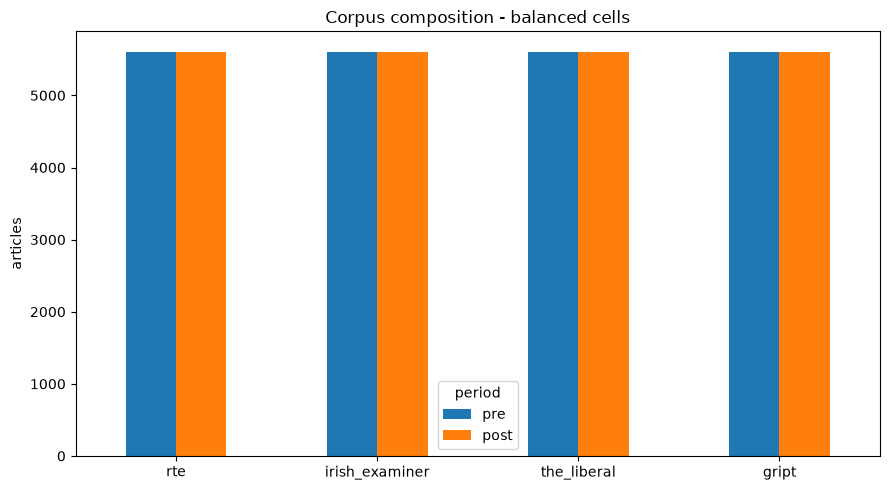

In [29]:
comp = df.pivot_table(index='outlet', columns='period', aggfunc='size', fill_value=0)[
    PERIOD_ORDER
].loc[OUTLET_ORDER]


fig, ax = plt.subplots(figsize=(9, 5))
comp.plot(kind='bar', ax=ax)
ax.set_title('Corpus composition - balanced cells')
ax.set_xlabel('')
ax.set_ylabel('articles')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='period')
fig.tight_layout()

### 1.2 Article length

Median length differs sharply: Gript and the Examiner run long, while **The Liberal is incredibly short-form**. Short text is exactly where zero-shot detectors are least reliable, as we will see, where RADAR false-positives. Because length is confounded with the legacy / counter-consensus split, it is reported alongside every detector result.

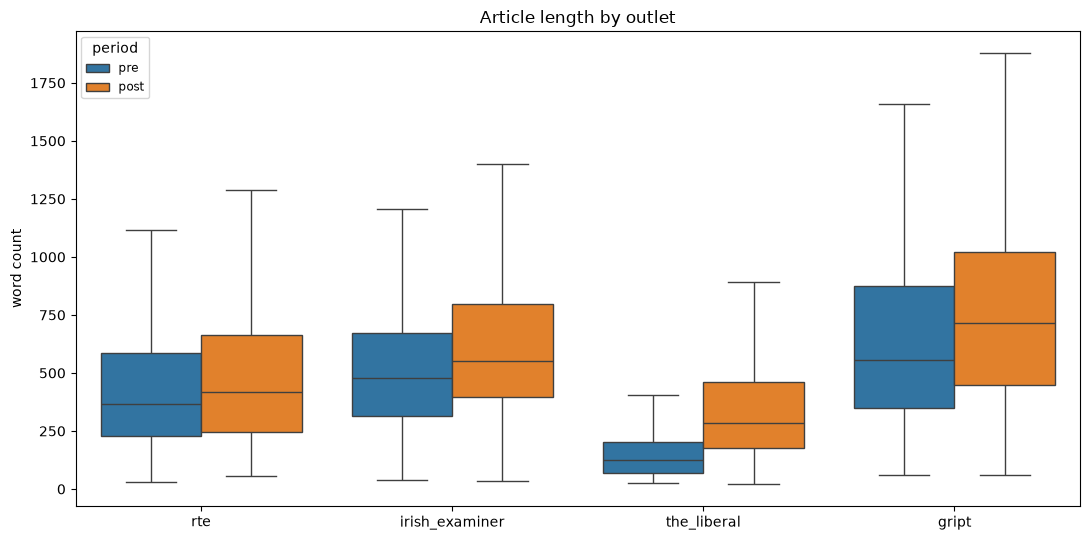

In [30]:
# Word-count distribution by outlet and period (clipped for readability).
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.boxplot(
    data=df,
    x='outlet',
    y='word_count',
    hue='period',
    order=OUTLET_ORDER,
    hue_order=PERIOD_ORDER,
    showfliers=False,
    ax=ax,
)
ax.set_title('Article length by outlet')
ax.set_xlabel('')
ax.set_ylabel('word count')
ax.legend(title='period', fontsize='small')
fig.tight_layout()

### 1.3 Wire and agency content

Wire copy is formulaic and reads as low-perplexity, so it skews detectors. It is concentrated in the **legacy** outlets, while it is near-zero at Liberal and Gript, and rises from pre to post at the Examiner. This is why wire is flagged and kept, and why the headline comparison is also reported wire-excluded.

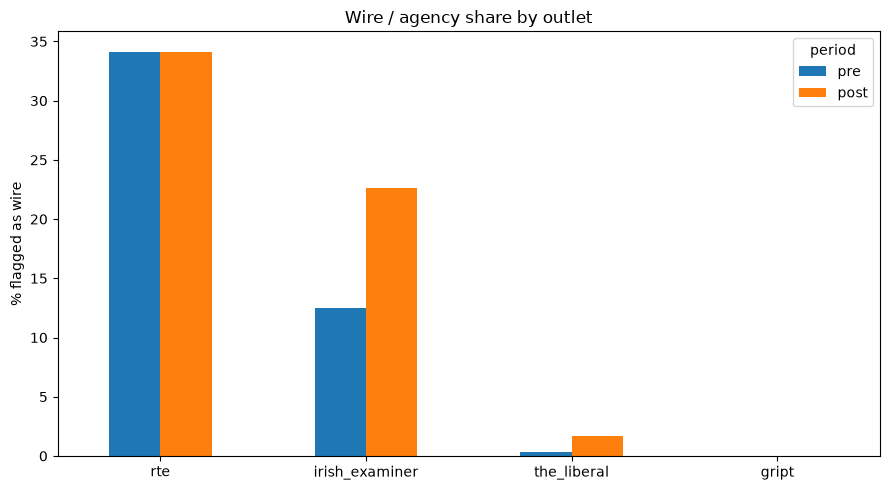

In [32]:
wire = (
    df.groupby(['outlet', 'period'])['is_wire'].mean()
    .unstack()[PERIOD_ORDER].loc[OUTLET_ORDER] * 100
)

fig, ax = plt.subplots(figsize=(9, 5))
wire.plot(kind='bar', ax=ax)
ax.set_title('Wire / agency share by outlet')
ax.set_xlabel('')
ax.set_ylabel('% flagged as wire')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='period')
fig.tight_layout()

## 2. Detector results

Four zero-shot detectors, each scoring every article so that **higher = more AI-like**. Their raw scales differ, so we are looking at *distributions* and *relative position*.

### 2.1 Scores by category and period

Per-detector boxplots split by outlet category and by period. We can see that many AI detectors do not distinguish well between pre-ChatGPT release and post-release: Perplexity does detect higher AI content in the post period; RADAR confounds on article length only; Binoculars is flat; FastdetectGPT is slightly higher on pre. This highlights a need for calibration on human-only and AI-generated datasets.

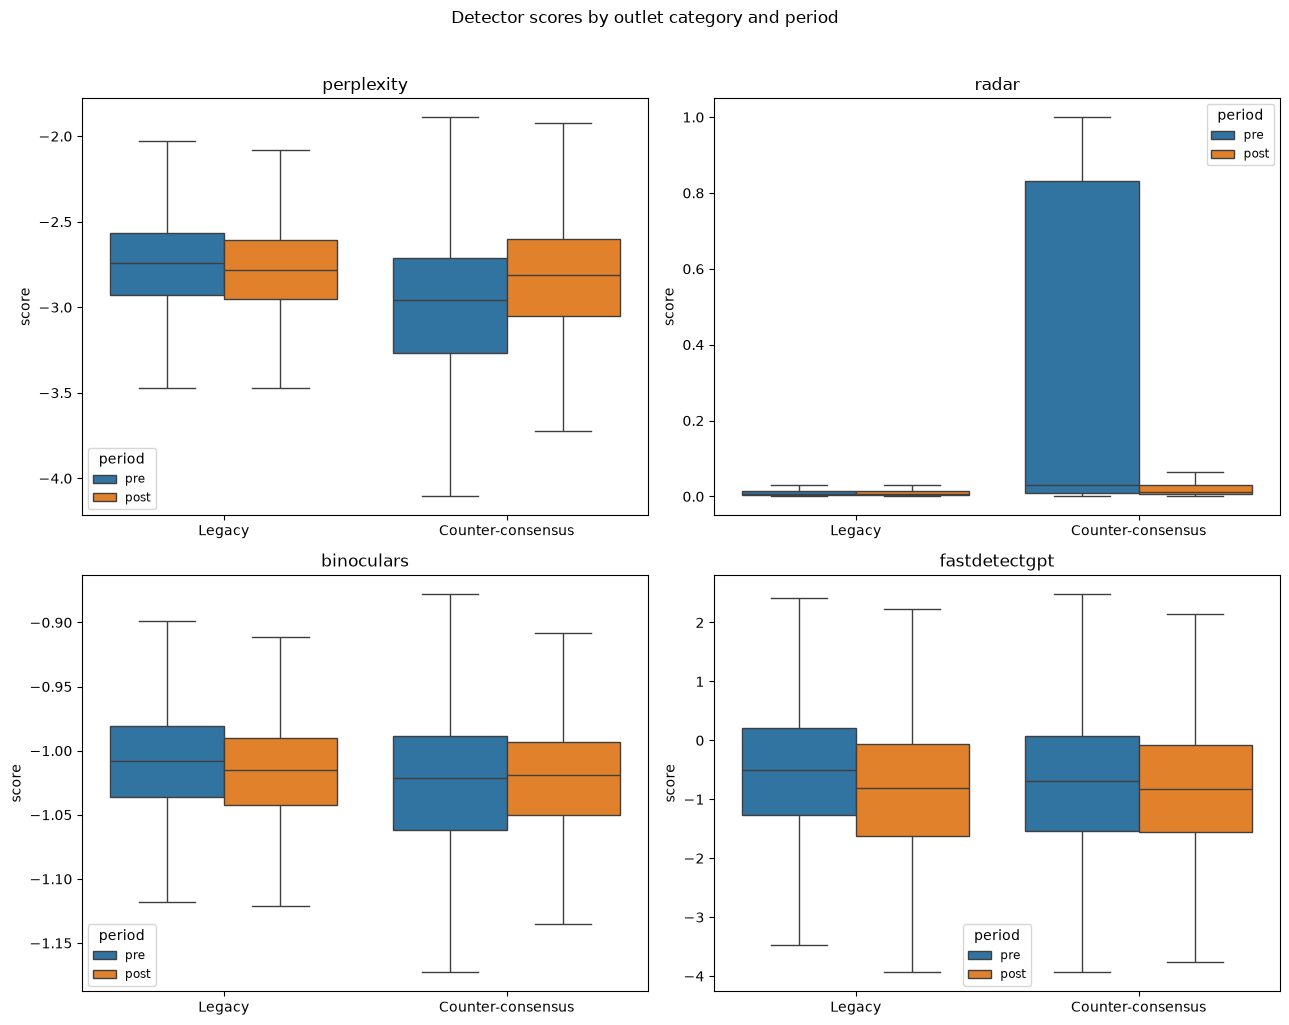

In [ ]:
# Per-detector score by category and period (separate axis each as scales differ).
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, detector in zip(axes.ravel(), DETECTORS, strict=False):
    sns.boxplot(
        data=df, x='category', y=f'{detector}_score', hue='period',
        order=CATEGORY_ORDER, hue_order=PERIOD_ORDER, showfliers=False, ax=ax,
    )
    ax.set_title(detector)
    ax.set_xlabel('')
    ax.set_ylabel('score')
    ax.legend(title='period', fontsize='small')
fig.suptitle('Detector scores by outlet category and period', y=1.02)
fig.tight_layout()

### 2.2 Do the detectors agree?

Each detector is a different method (perplexity, two curvature detectors, one adversarial), so agreement is evidence. **Spearman rank correlation** is scale-free — it asks whether they rank the same articles as more AI-like. Positive values mean the detectors corroborate one another; the z-scored overlay shows the shape of each distribution on a common axis.

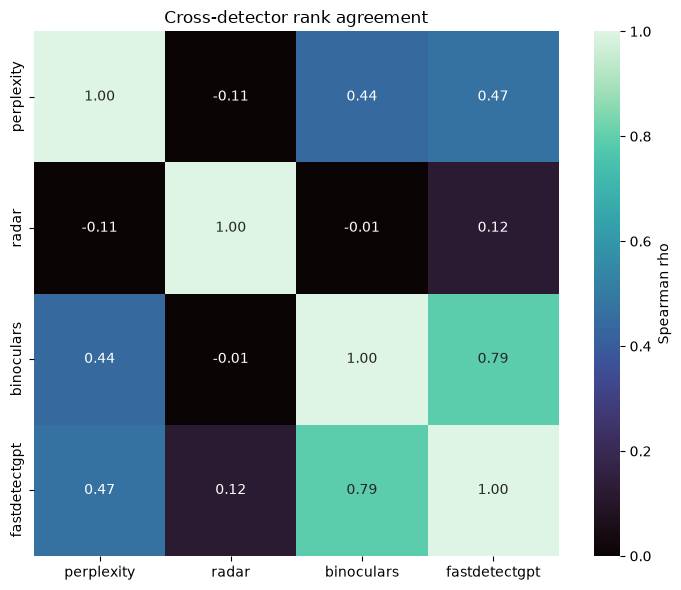

In [34]:
#AI Suggestion
# Spearman rank correlation between detectors (scale-free agreement).
corr = df[SCORE_COLS].corr(method='spearman')

corr.index = DETECTORS
corr.columns = DETECTORS

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='mako', vmin=0, vmax=1,
    square=True, cbar_kws={'label': 'Spearman rho'}, ax=ax,
)
ax.set_title('Cross-detector rank agreement')
fig.tight_layout()

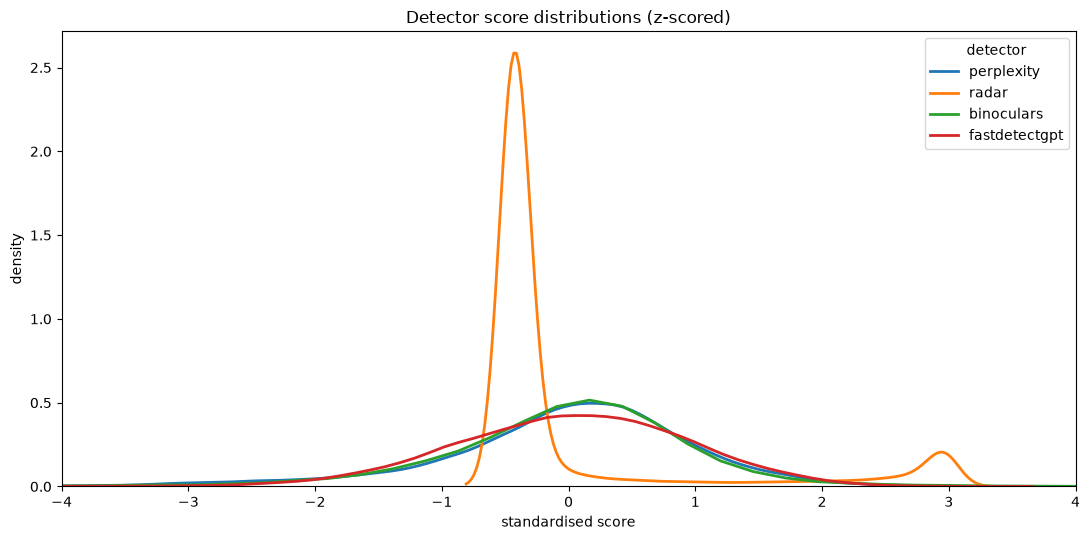

In [37]:
# Standardise each detector to mean 0 / sd 1 and overlay the distributions.
z = (df[SCORE_COLS] - df[SCORE_COLS].mean()) / df[SCORE_COLS].std()

fig, ax = plt.subplots(figsize=(11, 5.5))
for detector in DETECTORS:
    sns.kdeplot(z[f'{detector}_score'], ax=ax, label=detector, lw=2)
ax.set_xlim(-4, 4)
ax.set_title('Detector score distributions (z-scored)')
ax.set_xlabel('standardised score')
ax.set_ylabel('density')
ax.legend(title='detector')
fig.tight_layout()

### 2.3 RADAR's short-text artefact

RADAR assigns high AI-probability to **The Liberal's short PRE articles**, which predate ChatGPT and therefore *cannot* be AI-generated. It is a length artefact: RADAR misreads short text. Once a ~300-word floor is applied. Moving forward, a minimum 300 word floor will be applied. RADAR has been considered unreliable for AI text detection.

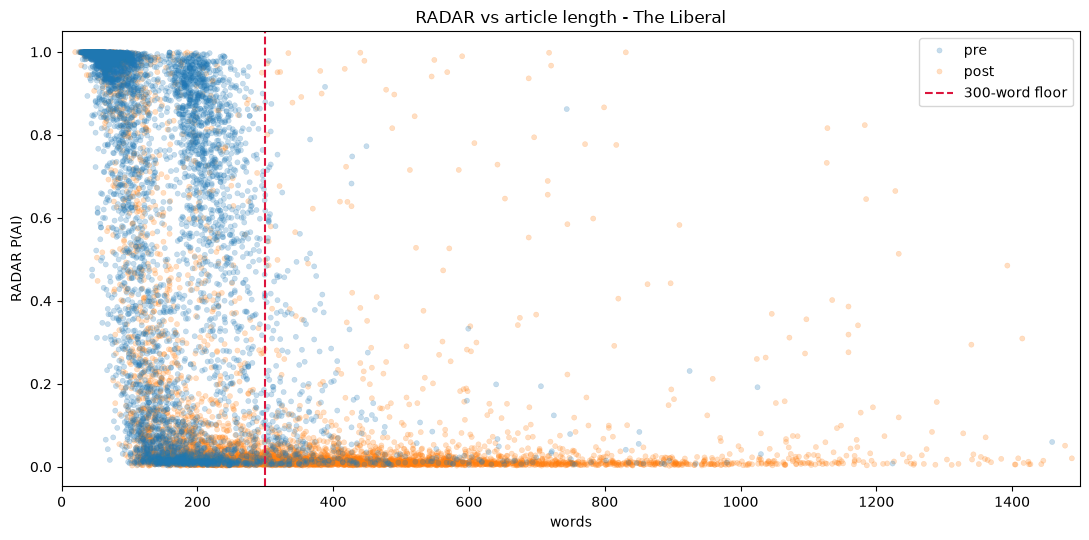

In [41]:
# RADAR score vs length for The Liberal, by period; 300-word floor marked.
liberal = df[df['outlet'] == 'the_liberal']

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.scatterplot(
    data=liberal, x='word_count', y='radar_score', hue='period',
    hue_order=PERIOD_ORDER, alpha=0.25, s=14, edgecolor=None, ax=ax,
)
ax.axvline(300, color='crimson', ls='--', lw=1.5, label='300-word floor')
ax.set_xlim(0, 1500)
ax.set_title('RADAR vs article length - The Liberal')
ax.set_xlabel('words')
ax.set_ylabel('RADAR P(AI)')
ax.legend(title='')
fig.tight_layout()

## Summary

- **Balanced, complete corpus.** 44,864 articles, all four detectors scored. The outlets differ structurally (length, wire) in ways that move detectors independently of AI. The 2023 gap will be filled and examined.
- **The detectors corroborate.** Positive rank agreement across four different methods gives an *ensemble* signal rather than any single method's verdict.
- **The clearest early result is methodological:** RADAR's short-text false positives on pre-ChatGPT Liberal articles — caught only because of the pre-ChatGPT control and the lower-bound framing.
- **Next step:** calibrate against the held-out human anchor and a known-AI set to turn these distributions into a lower-bound on AI share.
